# Fashion MNIST — CNN Classification
**Dataset:** [Zalando Research — Fashion MNIST](https://www.kaggle.com/datasets/zalando-research/fashionmnist)  
70,000 grayscale 28×28 images across 10 clothing categories.

## 1. Imports & Config

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

TensorFlow: 2.19.0
GPU available: False


## 2. Load Data

In [17]:
train_df = pd.read_csv('/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv')
test_df  = pd.read_csv('/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_test.csv')

print('Train shape:', train_df.shape)
print('Test shape: ', test_df.shape)

X_train = train_df.drop('label', axis=1).values.reshape(-1, 28, 28, 1).astype('float32') / 255.0
y_train = train_df['label'].values

X_test  = test_df.drop('label', axis=1).values.reshape(-1, 28, 28, 1).astype('float32') / 255.0
y_test  = test_df['label'].values

print('\nX_train:', X_train.shape, '| X_test:', X_test.shape)

Train shape: (60000, 785)
Test shape:  (10000, 785)

X_train: (60000, 28, 28, 1) | X_test: (10000, 28, 28, 1)


## 3. Exploratory Data Analysis

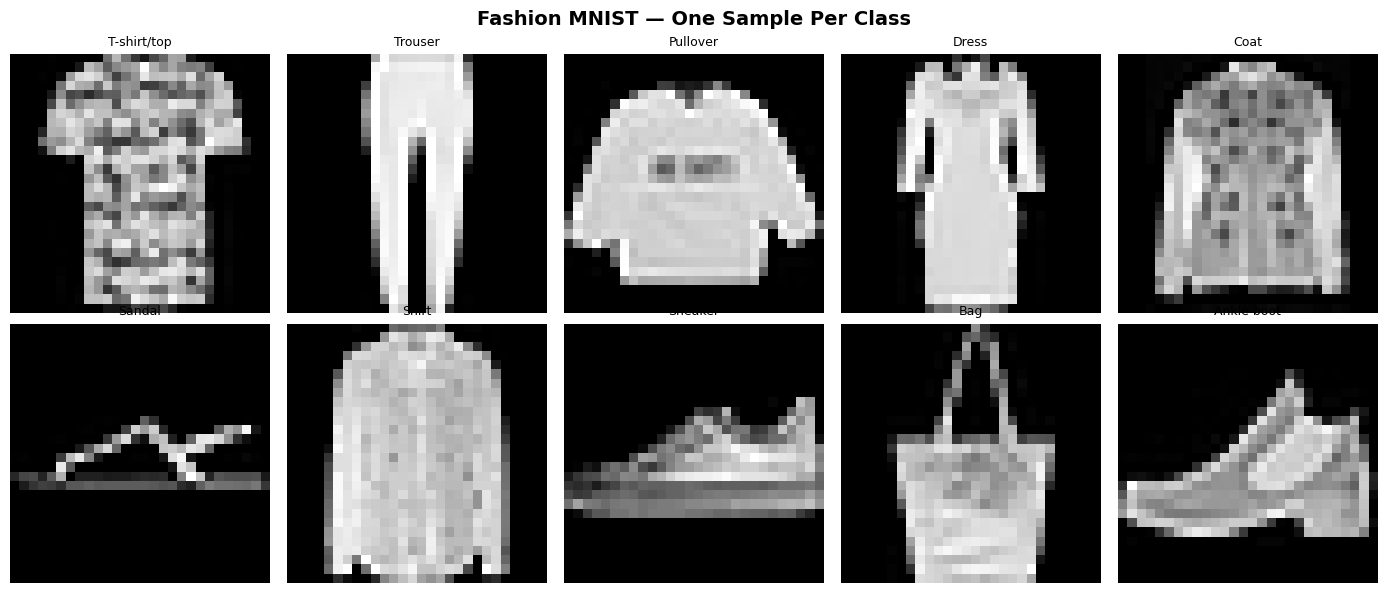

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Fashion MNIST — One Sample Per Class', fontsize=14, fontweight='bold')

for cls_idx, ax in enumerate(axes.flat):
    img_idx = np.where(y_train == cls_idx)[0][0]
    ax.imshow(X_train[img_idx].squeeze(), cmap='gray')
    ax.set_title(CLASS_NAMES[cls_idx], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

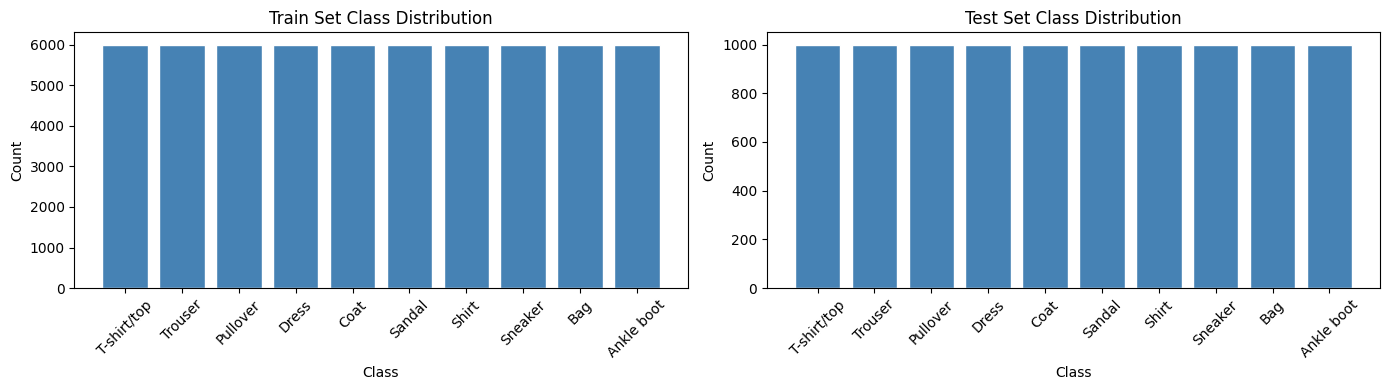

Dataset is perfectly balanced — 6,000 train / 1,000 test samples per class.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (labels, title) in zip(axes, [(y_train, 'Train'), (y_test, 'Test')]):
    counts = pd.Series(labels).value_counts().sort_index()
    ax.bar([CLASS_NAMES[i] for i in counts.index], counts.values, color='steelblue', edgecolor='white')
    ax.set_title(f'{title} Set Class Distribution')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print('Dataset is perfectly balanced — 6,000 train / 1,000 test samples per class.')

## 4. Data Augmentation

In [20]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name='augmentation')

## 5. CNN Architecture

In [21]:
def build_cnn(input_shape=(28, 28, 1), num_classes=10):
    inputs = keras.Input(shape=input_shape, name='input')

    x = data_augmentation(inputs)

    # Block 1
    x = layers.Conv2D(32, 3, padding='same', name='conv1a')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, 3, padding='same', name='conv1b')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2, name='pool1')(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding='same', name='conv2a')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same', name='conv2b')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2, name='pool2')(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding='same', name='conv3a')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, 3, padding='same', name='conv3b')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dropout(0.4)(x)

    # Classifier head
    x = layers.Dense(256, activation='relu', name='fc1')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return keras.Model(inputs, outputs, name='FashionMNIST_CNN')


model = build_cnn()
model.summary()

Model: "FashionMNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1a (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1b (Conv2D)                 │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2a (Conv2D)                 │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2b (Conv2D)                 │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3a (Conv2D)                 │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3b (Conv2D)                 │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 323,818 (1.24 MB)

 Trainable params: 322,922 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

## 6. Compile & Train

In [22]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cb_list = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-6, verbose=1
    ),
    callbacks.ModelCheckpoint(
        'best_model.keras', monitor='val_accuracy',
        save_best_only=True, verbose=0
    )
]

history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=50,
    batch_size=64,
    callbacks=cb_list,
    verbose=1
)

Epoch 1/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 171s 206ms/step - accuracy: 0.5543 - loss: 1.1922 - val_accuracy: 0.5800 - val_loss: 1.4500 - learning_rate: 0.0010
Epoch 2/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 166s 208ms/step - accuracy: 0.7484 - loss: 0.6827 - val_accuracy: 0.7078 - val_loss: 0.8213 - learning_rate: 0.0010
Epoch 3/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 163s 205ms/step - accuracy: 0.7861 - loss: 0.5961 - val_accuracy: 0.8079 - val_loss: 0.5199 - learning_rate: 0.0010
Epoch 4/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 164s 206ms/step - accuracy: 0.8066 - loss: 0.5427 - val_accuracy: 0.8439 - val_loss: 0.4437 - learning_rate: 0.0010
Epoch 5/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 162s 204ms/step - accuracy: 0.8174 - loss: 0.5101 - val_accuracy: 0.8426 - val_loss: 0.4237 - learning_rate: 0.0010
Epoch 6/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 161s 201ms/step - accuracy: 0.8277 - loss: 0.4794 - val_accuracy: 0.8224 - val_loss: 0.4799 - learning_rate: 0.0010
Epoch 7/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 160s 201ms/step - accura

## 7. Training Curves

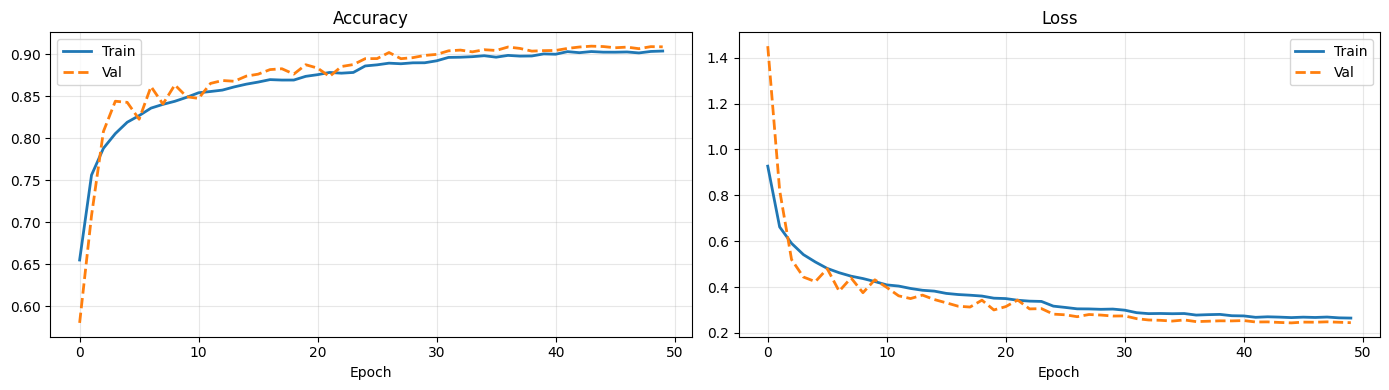

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric, title in zip(
    axes,
    [('accuracy', 'val_accuracy'), ('loss', 'val_loss')],
    ['Accuracy', 'Loss']
):
    train_key, val_key = metric
    ax.plot(history.history[train_key], label='Train', linewidth=2)
    ax.plot(history.history[val_key],   label='Val',   linewidth=2, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Evaluation on Test Set

In [24]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')

Test Loss     : 0.2372
Test Accuracy : 0.9130 (91.30%)


## 9. Classification Report & Confusion Matrix

In [25]:
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.87      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.91      0.87      0.89      1000
       Dress       0.94      0.90      0.92      1000
        Coat       0.88      0.85      0.87      1000
      Sandal       0.99      0.96      0.97      1000
       Shirt       0.72      0.78      0.75      1000
     Sneaker       0.92      0.98      0.95      1000
         Bag       0.97      0.99      0.98      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.92      0.91      0.91     10000
weighted avg       0.92      0.91      0.91     10000



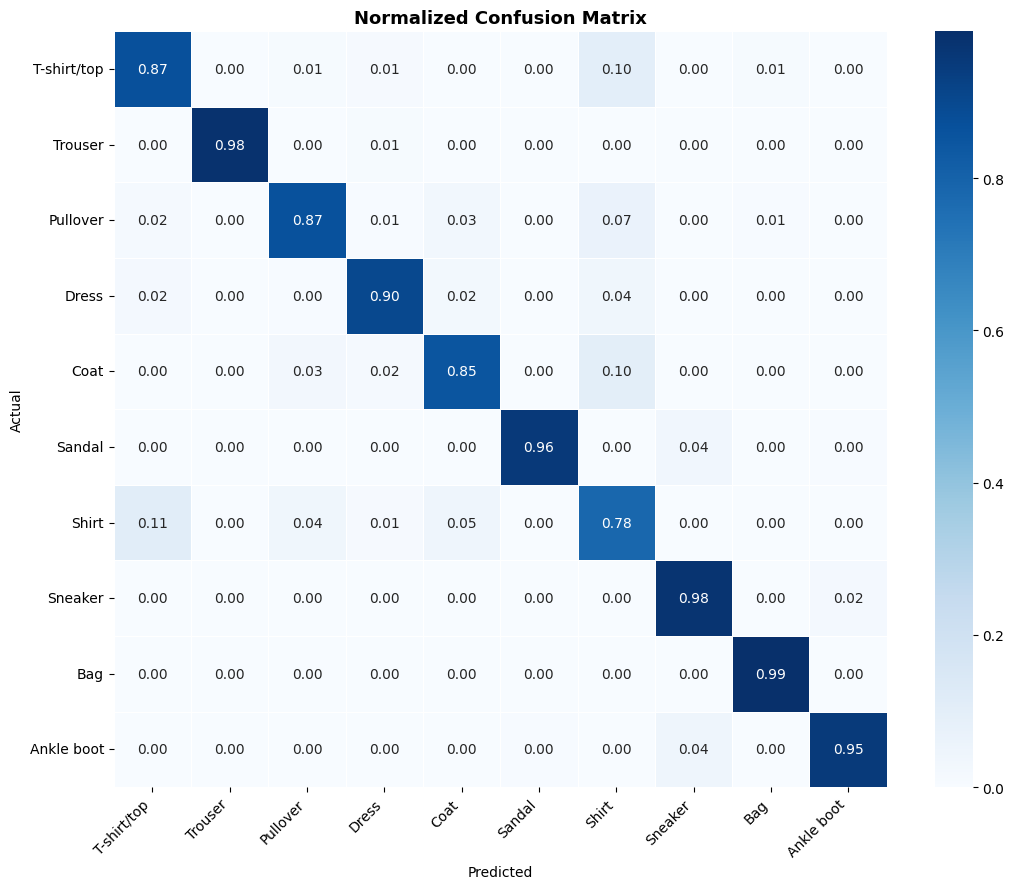

In [26]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax
)
ax.set_title('Normalized Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Error Analysis — Hard Cases

Total misclassified: 870 / 10000 (8.70%)


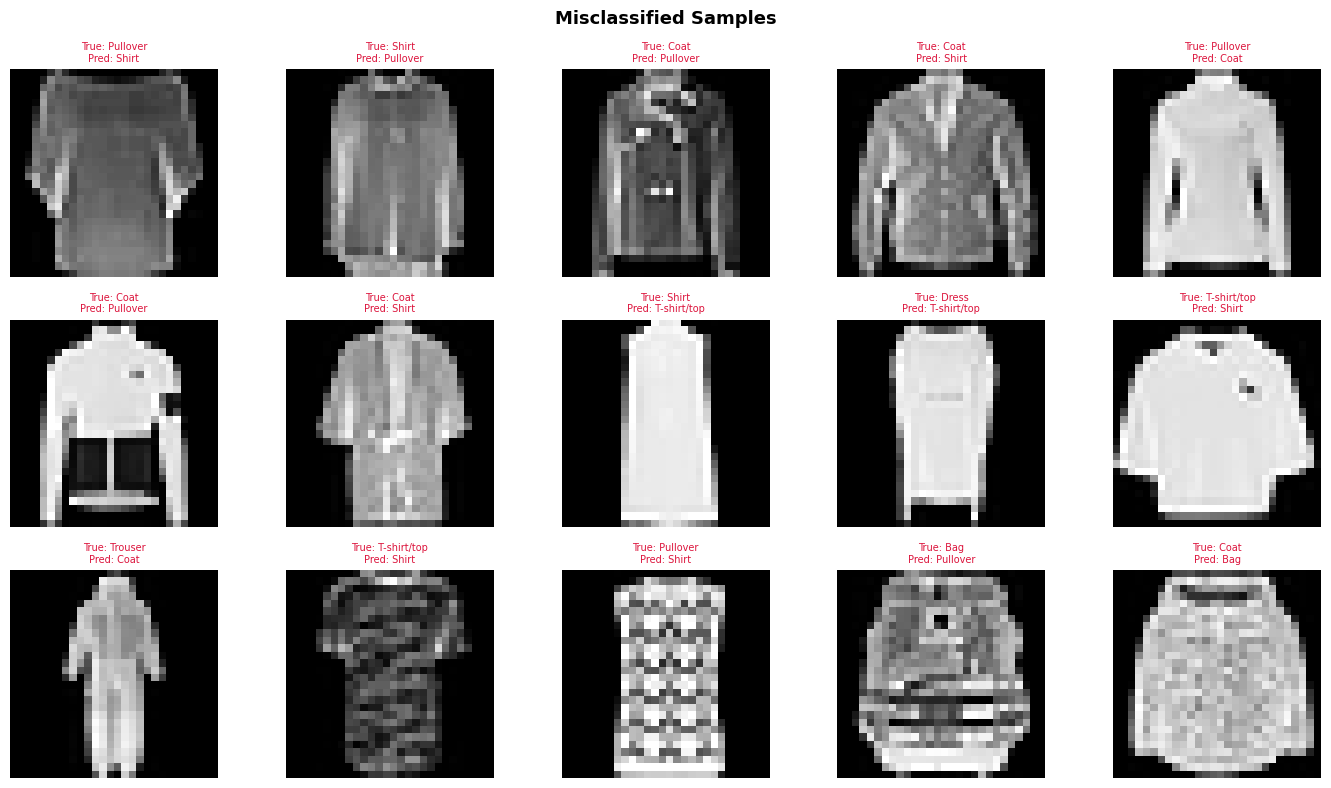

In [27]:
wrong_idx = np.where(y_pred != y_test)[0]
print(f'Total misclassified: {len(wrong_idx)} / {len(y_test)} ({len(wrong_idx)/len(y_test)*100:.2f}%)')

sample = wrong_idx[:15]
fig, axes = plt.subplots(3, 5, figsize=(14, 8))
fig.suptitle('Misclassified Samples', fontsize=13, fontweight='bold')

for ax, idx in zip(axes.flat, sample):
    ax.imshow(X_test[idx].squeeze(), cmap='gray')
    ax.set_title(
        f'True: {CLASS_NAMES[y_test[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}',
        fontsize=7, color='crimson'
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

## 11. Feature Map Visualization

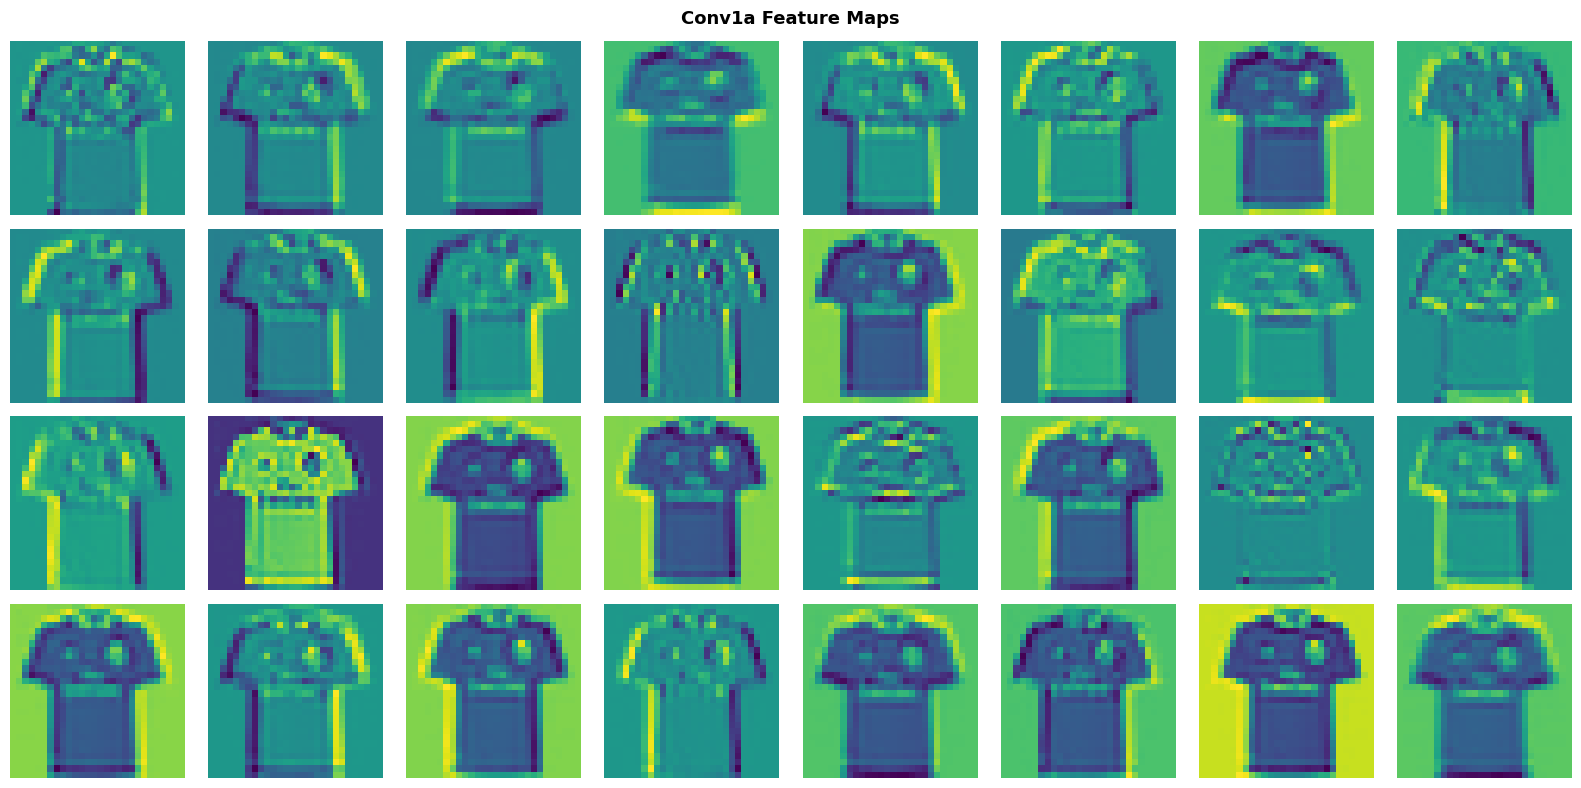

In [28]:
activation_model = keras.Model(
    inputs=model.input,
    outputs=model.get_layer('conv1a').output
)

sample_img = X_test[0:1]
feature_maps = activation_model.predict(sample_img, verbose=0)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('Conv1a Feature Maps', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < feature_maps.shape[-1]:
        ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Summary

| Component | Detail |
|---|---|
| Architecture | 3 Conv blocks (32→64→128) + GAP + Dense head |
| Regularization | BatchNorm, Dropout (0.25 / 0.4 / 0.5) |
| Augmentation | Flip, Rotate, Zoom, Translate |
| Optimizer | Adam with ReduceLROnPlateau |
| Expected Test Acc | ~93–94% |